In [6]:
# import os
# import random #데이터 샘플링
# from collections import Counter # count 용도

import numpy as np
import pandas as pd

from tqdm import tqdm

# 결측치 확인
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')

# 한글, 마이너스 깨짐 방지
from matplotlib import rc, font_manager, rcParams
font=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family = font)
rcParams['axes.unicode_minus'] = False

# 지도
# from geopy import distance # 거리 계산
# import geopy.distance
import folium
from folium.plugins import HeatMap

# # plotly
# import ipywidgets as widgets
# from ipywidgets import interact

# # 이걸 설정하면 Multiple Output이 가능함
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"

# import chart_studio.plotly as py 
# import plotly.express as px
# import cufflinks as cf 
# cf.go_offline(connected=True)

# import plotly.graph_objects as go

## 데이터 불러오기

In [2]:
df = pd.read_csv('./dataset/restaurant_pre.csv')
df

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance
0,진미평양냉면,냉면,논현동 115-10,3.7,204,532,37.516107,127.036030,669.698432
1,대가방 본점,중화요리,논현동 99-7,3.3,86,101,37.521115,127.038526,1233.413552
2,세종한우 2호점,"육류,고기",논현동 216-10,3.0,27,42,37.510889,127.032509,235.981638
3,크래버대게나라 강남점,"게,대게",논현동 261,4.1,38,188,37.511590,127.036288,528.555530
4,카페써드,커피전문점,논현동 118-4,3.7,12,100,37.517362,127.039830,1020.061748
...,...,...,...,...,...,...,...,...,...
494,스윙부스,카페,논현동 151-17,5.0,4,15,37.511115,127.030901,122.943185
495,60계 서울논현점,치킨,논현동 183-2,3.6,8,24,37.506444,127.024751,800.969261
496,필스너하우스 청담점,"호프,요리주점",논현동 96-12,4.6,7,15,37.521158,127.037377,1180.985491
497,웨이크업커피 2호점,카페,논현동 86-4,5.0,1,3,37.515219,127.031794,367.396766


In [3]:
for col in df.columns:
    print(f"column : {col}")
    print(f"The number of unique : {df[col].nunique()}")
    print()

column : name
The number of unique : 499

column : category
The number of unique : 71

column : address
The number of unique : 436

column : score
The number of unique : 38

column : eval_cnt
The number of unique : 59

column : review_cnt
The number of unique : 129

column : lat
The number of unique : 435

column : lng
The number of unique : 435

column : distance
The number of unique : 435



In [9]:
def aca_map(zoom=16, marker=True, circle=True, tile='OpenStreetMap'):
    aca_geo = (37.5121248, 127.030334)
    m = folium.Map(aca_geo, zoom_start=zoom, tiles=tile)
    if marker:
        folium.Marker(aca_geo,  icon=folium.Icon(
            color='gray', icon='glyphicon glyphicon-flag')).add_to(m)
    if circle:
        folium.Circle(aca_geo, radius=700, color='',
              fill_color='gray', fill_opacity=.3).add_to(m)
    return m

In [10]:
m = aca_map(zoom=15, circle=False)
HeatMap(df[['lat', 'lng']], radius=14).add_to(m)
# MarkerCluster(df[['lat', 'lng']]).add_to(m)

m

In [11]:
df['category'].unique()

array(['냉면', '중화요리', '육류,고기', '게,대게', '커피전문점', '한식', '곱창,막창', '족발,보쌈',
       '돈까스,우동', '조개', '초밥,롤', '일식', '카페', '삼계탕', '양식', '디저트카페', '장어',
       '중식', '일본식라면', '갈비', '퓨전일식', '샤브샤브', '일본식주점', '삼겹살', '해물,생선', '국수',
       '떡볶이', '닭요리', '호프,요리주점', '갤러리카페', '이탈리안', '패밀리레스토랑', '한정식', '회',
       '양꼬치', '참치회', '사철탕,영양탕', '북카페', '퓨전요리', '실내포장마차', '아구', '일식집',
       '햄버거', '제과,베이커리', '수제비', '설렁탕', '복어', '찌개,전골', '치킨', '매운탕,해물탕',
       '해장국', '태국음식', '피자', '순대', '술집', '패스트푸드', '와인바', '칵테일바', '베트남음식',
       '애견카페', '국밥', '다방', '불고기,두루치기', '감자탕', '샌드위치', '동남아음식', '분식',
       '음식점', '죽', '도시락', '굴,전복'], dtype=object)

In [19]:
df[df['category']=='냉면']

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance
0,진미평양냉면,냉면,논현동 115-10,3.7,204,532,37.516107,127.036030,669.698432
20,평양면옥,냉면,논현동 66-2,3.1,73,73,37.518904,127.029148,760.993943
86,봉산평양냉면,냉면,논현동 49-8,4.3,24,47,37.512773,127.021640,770.246676
110,한교방서울면옥,냉면,논현동 117-8,2.7,11,48,37.516796,127.038078,858.076456
358,신사면옥,냉면,논현동 96,3.3,4,6,37.521248,127.036621,1156.116127


In [18]:
df[df['category']=='중화요리']

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance
1,대가방 본점,중화요리,논현동 99-7,3.3,86,101,37.521115,127.038526,1233.413552
12,홍명,중화요리,논현동 37-9,3.5,82,104,37.514490,127.029443,274.499144
13,일일향 2호점,중화요리,논현동 206-5,3.4,29,54,37.507208,127.032245,572.089695
40,취영루 논현점,중화요리,논현동 141-3,2.9,24,64,37.510533,127.022741,692.710355
82,주방류,중화요리,논현동 145-10,4.5,25,49,37.509400,127.024794,574.929906
102,왕스덕,중화요리,논현동 4-18,3.7,9,15,37.517059,127.022975,849.865418
106,JS가든블랙,중화요리,논현동 96-3,4.2,5,65,37.521456,127.036947,1190.268639
119,공리 강남구청역점,중화요리,논현동 240-14,3.4,14,103,37.516023,127.039505,917.708289
130,뽕사부,중화요리,논현동 111-28,3.9,9,14,37.518128,127.040500,1117.780330
147,나향반점,중화요리,논현동 277-1,4.3,12,74,37.509860,127.040072,895.057182


In [15]:
df.category.value_counts()

육류,고기      58
커피전문점      31
해물,생선      23
카페         21
중화요리       19
           ..
패밀리레스토랑     1
갤러리카페       1
샤브샤브        1
죽           1
굴,전복        1
Name: category, Length: 71, dtype: int64

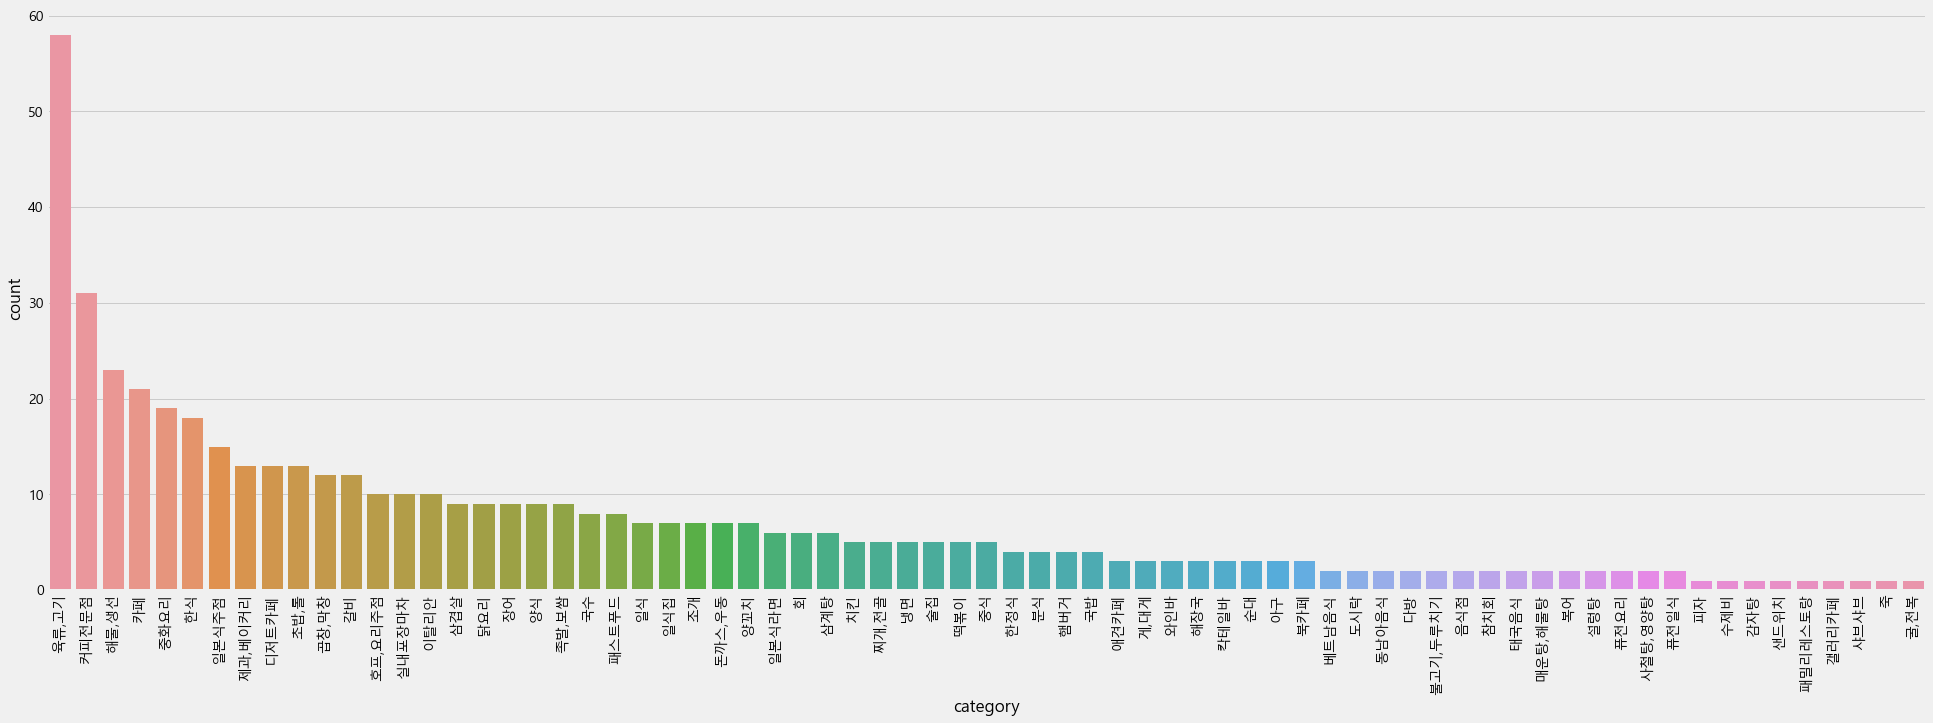

In [16]:
plt.figure(figsize=(30, 10))
sns.countplot(df.category, order=df.category.value_counts().index)
plt.xticks(rotation=90)
plt.show()